# Training - version 1 hyperparameters

**In:** `data/split` (frozen by model selection)  
**Out:** MLflow run tagged `version=v1`

| Step | What |
| --- | --- |
| 1 | Load the frozen split |
| 2 | v1 hyperparameters |
| 3 | Train and log |
| 4 | Predicted vs actual |

Model selection chose HistGradientBoosting with Poisson loss. v1 is the untuned
reference point: the tuned sweep has to beat these numbers to justify itself.

Comparing versions happens in evaluation, not here.

## Step 1 - Load the frozen split

Reading `data/split` rather than re-deriving from `data/featured`: v1 and v2 are
only comparable if they saw byte-identical rows. `split.json` carries the
feature contract, so the column list is never retyped.

In [1]:
import json
import os
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SPLIT = Path("/opt/data/ml/split")

contract = json.loads((SPLIT / "split.json").read_text())
TARGET = contract["target"]
FEATURES = contract["features"]
PEAK_HOURS = contract["peak_hours"]

train = pd.read_parquet(SPLIT / "train.parquet")
val = pd.read_parquet(SPLIT / "val.parquet")
test = pd.read_parquet(SPLIT / "test.parquet")

# The split is frozen upstream, but a corrupted or re-generated file would
# silently invalidate every metric below.
assert train["start_date"].max() < val["start_date"].min(), "train/val overlap"
assert val["start_date"].max() < test["start_date"].min(), "val/test overlap"
assert set(FEATURES).issubset(train.columns), "split is missing a contracted feature"

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("bike-demand")

for name, df in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:6} {len(df):>9,} rows  "
          f"{df['start_date'].min().date()} .. {df['start_date'].max().date()}")
print(f"\n{len(FEATURES)} features -> {TARGET}")

train  1,999,104 rows  2019-01-01 .. 2021-12-31
val      611,040 rows  2022-01-01 .. 2022-12-31
test     665,760 rows  2023-01-01 .. 2023-12-31

15 features -> trip_count


## Step 2 - v1 hyperparameters

sklearn defaults, deliberately untuned - v1 is the reference, not an attempt at
a good model.

`early_stopping` stays off: sklearn draws its internal validation holdout at
**random**, which on a chronological split would put 2021 rows in the stopping
set while training on 2019.

In [2]:
V1_PARAMS = {
    "loss": "poisson",       # counts are non-negative and skewed
    "learning_rate": 0.1,
    "max_leaf_nodes": 31,
    "max_iter": 300,
    "min_samples_leaf": 20,
    "l2_regularization": 0.0,
    "early_stopping": False,
    "random_state": 0,
}

DATA_CONTEXT = {
    "rows_train": len(train),
    "rows_val": len(val),
    "rows_test": len(test),
    "n_stations": train["station_id"].nunique(),
    "train_years": str(contract["train_years"]),
    "val_years": str(contract["val_years"]),
    "test_years": str(contract["test_years"]),
    "features": ",".join(FEATURES),
}

pd.Series(V1_PARAMS).to_frame("v1")

,v1
loss,poisson
learning_rate,0.1
max_leaf_nodes,31
max_iter,300
min_samples_leaf,20
l2_regularization,0.0
early_stopping,False
random_state,0


## Step 3 - Train and log

In [3]:
def score(y_true, y_pred, hours):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    peak = np.isin(hours, PEAK_HOURS)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE_peak": mean_absolute_error(y_true[peak], y_pred[peak]),
        "MAE_offpeak": mean_absolute_error(y_true[~peak], y_pred[~peak]),
    }


# season is the only string column; everything else passes through as numeric.
model = Pipeline([
    ("prep", ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
          ["season"])],
        remainder="passthrough",
    )),
    ("model", HistGradientBoostingRegressor(**V1_PARAMS)),
])

In [4]:
%%time
with mlflow.start_run(run_name="hist_gbm_v1") as run:
    mlflow.log_params(V1_PARAMS)
    mlflow.set_tags({"model": "hist_gbm", "version": "v1", **DATA_CONTEXT})

    model.fit(train[FEATURES], train[TARGET])

    rows = []
    for split_name, df in [("val", val), ("test", test)]:
        s = score(df[TARGET], model.predict(df[FEATURES]), df["hour"])
        mlflow.log_metrics({f"{split_name}_{k}": v for k, v in s.items()})
        rows.append({"split": split_name, **s})

    mlflow.sklearn.log_model(model, name="model")
    run_id = run.info.run_id

v1_scores = pd.DataFrame(rows).set_index("split")
print(f"run_id {run_id}")
v1_scores

🏃 View run hist_gbm_v1 at: http://mlflow:5000/#/experiments/1/runs/40800400095b4e0bbb4dbb7c467f6224
🧪 View experiment at: http://mlflow:5000/#/experiments/1
run_id 40800400095b4e0bbb4dbb7c467f6224
CPU times: user 4min 6s, sys: 2.26 s, total: 4min 9s
Wall time: 1min 3s


,MAE,RMSE,MAE_peak,MAE_offpeak
split,,,,
val,1.408149,2.581822,2.007490,1.161361
test,1.725368,3.075830,2.663388,1.339125


## Step 4 - Predicted vs actual

Aggregate metrics say how far off the model is on average; they do not say
whether it reproduces the *shape* of a day. These two views do.

Both are computed on test (2023) - the split the model never saw.

In [5]:
test_pred = np.clip(model.predict(test[FEATURES]), 0, None)

actual_vs_pred = test[["station_id", "start_date", "hour", TARGET]].copy()
actual_vs_pred["predicted"] = test_pred

# Average day: every station-hour in 2023 collapsed to 24 points.
by_hour = actual_vs_pred.groupby("hour")[[TARGET, "predicted"]].mean()

# One busy station over one week, so the daily shape is visible rather than
# averaged away.
busiest = actual_vs_pred.groupby("station_id")[TARGET].sum().idxmax()
week = actual_vs_pred[
    (actual_vs_pred["station_id"] == busiest)
    & (actual_vs_pred["start_date"] >= "2023-06-05")
    & (actual_vs_pred["start_date"] <= "2023-06-11")
].sort_values(["start_date", "hour"]).reset_index(drop=True)

print(f"busiest station in test: {busiest}")
print(f"week sample: {len(week)} hours")
by_hour.head()

busiest station in test: 7006
week sample: 168 hours


,trip_count,predicted
hour,,
0,0.865357,0.454333
1,0.567087,0.284372
2,0.402704,0.185683
3,0.207102,0.100630
4,0.148089,0.068844


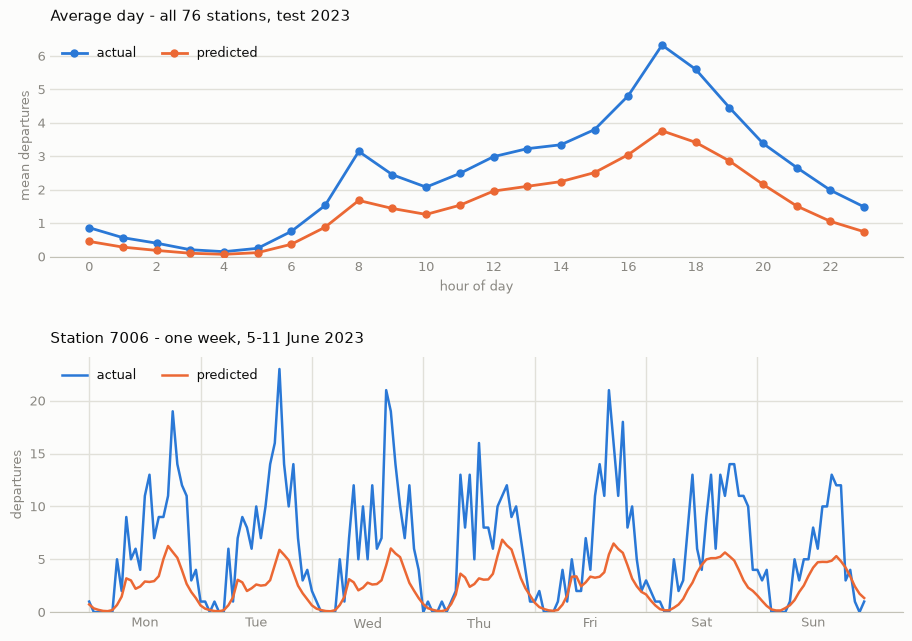

In [6]:
import matplotlib.pyplot as plt

# Validated categorical slots: blue = actual, orange = predicted.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID_C, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 7.5), facecolor=SURFACE,
    gridspec_kw={"height_ratios": [1, 1.15], "hspace": 0.42},
)

# --- average day across all stations ---
ax1.plot(by_hour.index, by_hour[TARGET], color=BLUE, linewidth=2,
         marker="o", markersize=5, label="actual", zorder=3)
ax1.plot(by_hour.index, by_hour["predicted"], color=ORANGE, linewidth=2,
         marker="o", markersize=5, label="predicted", zorder=3)
ax1.set_xticks(range(0, 24, 2))
ax1.set_xlabel("hour of day", fontsize=9, color=MUTED)
ax1.set_ylabel("mean departures", fontsize=9, color=MUTED)
ax1.set_title("Average day - all 76 stations, test 2023",
              fontsize=11, color=INK, loc="left", pad=10)

# --- one station, one week ---
ax2.plot(week.index, week[TARGET], color=BLUE, linewidth=1.8,
         label="actual", zorder=3)
ax2.plot(week.index, week["predicted"], color=ORANGE, linewidth=1.8,
         label="predicted", zorder=3)

# day boundaries every 24 hours, labelled with the weekday
day_starts = range(0, len(week), 24)
for d in day_starts:
    ax2.axvline(d, color=GRID_C, linewidth=1, zorder=1)
ax2.set_xticks(
    [d + 12 for d in day_starts],
    [week.loc[d, "start_date"].strftime("%a") for d in day_starts],
    fontsize=9, color=INK,
)
ax2.set_ylabel("departures", fontsize=9, color=MUTED)
ax2.set_title(f"Station {busiest} - one week, 5-11 June 2023",
              fontsize=11, color=INK, loc="left", pad=10)

for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    ax.yaxis.grid(True, color=GRID_C, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(bottom=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="both", length=0, colors=MUTED, labelsize=9)
    ax.legend(frameon=False, ncols=2, fontsize=9, labelcolor=INK, loc="upper left")

fig.savefig("/tmp/v1-pred-vs-actual.png", dpi=140, facecolor=SURFACE,
            bbox_inches="tight")
plt.show()

In [7]:
# Where the error sits by demand level. A model that only ever predicts the mean
# looks fine on average and fails exactly where rebalancing matters.
bands = pd.cut(actual_vs_pred[TARGET], [-0.1, 0, 2, 5, 10, np.inf],
               labels=["0", "1-2", "3-5", "6-10", "11+"])

by_band = actual_vs_pred.groupby(bands, observed=True).apply(
    lambda g: pd.Series({
        "rows": len(g),
        "mean_actual": g[TARGET].mean(),
        "mean_predicted": g["predicted"].mean(),
        "MAE": mean_absolute_error(g[TARGET], g["predicted"]),
    }),
    include_groups=False,
)
by_band["rows"] = by_band["rows"].astype(int)
by_band

,rows,mean_actual,mean_predicted,MAE
trip_count,,,,
0,267079,0.000000,0.551291,0.551291
1-2,179564,1.400787,1.161748,0.910090
3-5,122107,3.816194,2.086871,2.171847
6-10,71037,7.462182,3.283989,4.558438
11+,25973,14.935163,5.696908,9.587193
